<font color="FF3B3B"><h1 align="left">Proyecto de aprendizaje profundo</h1></font>
<font color="#6E6E6E"><h2 align="left">Modelo de transfer learning</h2></font>

##### David Alejandro Pedroza De Jesús
##### Joel Ezequiel Vicente Alonso

Cargamos las librerias para la realización del proyecto

In [1]:
import sys
sys.path.append("../")
import numpy as np
import pandas as pd
import cv2
import kagglehub
import os
from shutil import move
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras.utils import plot_model
from keras.applications.resnet import preprocess_input
from keras.optimizers import Adam
from modelos.Modelo_transfer import Modelo_transfer


In [3]:
path = kagglehub.dataset_download("gpiosenka/cards-image-datasetclassification")
print(path)

Using Colab cache for faster access to the 'cards-image-datasetclassification' dataset.
/kaggle/input/cards-image-datasetclassification


In [5]:
move(path,os.getcwd())

In [ ]:
os.rename("2","cards-image-datasetclassification")

# Resumen

En este notebook haremos uso de transfer learnig para ver si con un modelo podemos resolver el problema.Para este caso usaremos `ResNet152V2`

# Cargar las imagenes

Hararemos el procesado que hemos hecho antes, tanto con las etiquetas e imagenes.

In [6]:
datos = pd.read_csv(r"cards-image-datasetclassification/cards.csv")
datos.head()

,class index,filepaths,labels,card type,data set
0,0,train/ace of clubs/001.jpg,ace of clubs,ace,train
1,0,train/ace of clubs/002.jpg,ace of clubs,ace,train
2,0,train/ace of clubs/003.jpg,ace of clubs,ace,train
3,0,train/ace of clubs/004.jpg,ace of clubs,ace,train
4,0,train/ace of clubs/005.jpg,ace of clubs,ace,train


Arreglamos las rutas.

In [7]:
rutas_adaptadas = ["cards-image-datasetclassification/" +  ruta for ruta in datos["filepaths"]]
im_buenas = []
im_malas = []
for ru in rutas_adaptadas:
    im = cv2.imread(ru)
    if  im is not None:
        im_buenas.append(ru)
    else:
        im_malas.append(ru)
#print(f"Lecturas correctas: {len(im_buenas)}")
#print(f"Lecturas incorrectas: {len(im_malas)}")

df_limpio = datos[np.array(rutas_adaptadas) != np.array(im_malas)]
df_limpio["rutas_adap"] = im_buenas

/tmp/ipykernel_2220/1813950221.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio["rutas_adap"] = im_buenas


Ahora cargamos las imagenes, añadiremos un procesado más, debido a que no necesitamos toda la carta para realizar la predicción.Esta función es una versión modificada, donde aplica el preprocesado a cada imagen depues de cargarla.

In [8]:
def CargarImg_trans(path, size):
    img = cv2.imread(path)
    img_RGB = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)[0:75,0:75]#De con esto ya tenemos toda la información
    img_resize = cv2.resize(img_RGB, size)

    return preprocess_input(img_resize)

In [9]:
rutas_train = df_limpio[df_limpio["data set"] == "train"].rutas_adap
rutas_test = df_limpio[df_limpio["data set"] == "test"].rutas_adap
rutas_val = df_limpio[df_limpio["data set"] == "valid"].rutas_adap

X_train = np.array([CargarImg_trans(path, (75, 75)) for path in rutas_train])
X_test = np.array([CargarImg_trans(path, (75, 75)) for path in rutas_test])
X_val = np.array([CargarImg_trans(path, (75, 75)) for path in rutas_val])

y_train = df_limpio[df_limpio["data set"] == "train"]["labels"]
y_test = df_limpio[df_limpio["data set"] == "test"]["labels"]
y_val = df_limpio[df_limpio["data set"] == "valid"]["labels"]

Y codificamos los labels con `LabelEncoder()`

In [10]:
encoder = LabelEncoder()

y_train_num = encoder.fit_transform(y_train)
y_val_num   = encoder.transform(y_val)
y_test_num  = encoder.transform(y_test)

# Arquitectura de la red

Como hemos dicho antes, usaremos como estractor de caracteristicas una **ResNet**, luego le añadiremos a la arquitectura una capa de `GlobalAveragePooling2D` y luego una capa de flatten para adapatar la red a nuestro problema particular.

In [11]:
input_shape = X_train[0].shape
num_clases = np.unique(y_train_num).shape[0]
model = Modelo_transfer(input_shape, num_clases)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, None,      │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,472 │ conv1_pad[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, None,      │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, None,      │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, None,      │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, None,      │          0 │ conv2_block1_1_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, None,      │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, None,      │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, None,      │          0 │ conv2_block1_2_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, None,      │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, None,      │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, None,      │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, None,      │      1,024 │ conv2_block1_3_c

 Total params: 24,126,901 (92.04 MB)

 Trainable params: 538,677 (2.05 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

También aquí hacemos un plot de la arquitectura del modelo.

In [ ]:
plot_model(model, show_shapes=True)

# Entrenamiento

En este apartado realizaremos el entrenamiento.

In [ ]:
hist = model.fit(X_train, y_train_num,validation_data=(X_val, y_val_num), epochs=50)

Epoch 1/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 34s 78ms/step - loss: 2.9923 - sparse_categorical_accuracy: 0.2143 - val_loss: 2.1480 - val_sparse_categorical_accuracy: 0.3547
Epoch 2/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 2.0777 - sparse_categorical_accuracy: 0.4023 - val_loss: 1.9059 - val_sparse_categorical_accuracy: 0.3849
Epoch 3/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 1.7097 - sparse_categorical_accuracy: 0.5012 - val_loss: 1.7417 - val_sparse_categorical_accuracy: 0.4226
Epoch 4/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 1.4649 - sparse_categorical_accuracy: 0.5645 - val_loss: 1.6310 - val_sparse_categorical_accuracy: 0.4792
Epoch 5/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 1.2879 - sparse_categorical_accuracy: 0.6076 - val_loss: 1.7010 - val_sparse_categorical_accuracy: 0.4453
Epoch 6/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 1.1345 - sparse_categorical_accuracy: 0.6579 - val_loss: 1.6987 - val_sparse_categorical_accuracy: 0.48

# Fine tunnig

In [ ]:
for layer in model.layers[-60:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

In [ ]:
hist = model.fit(X_train, y_train_num,validation_data=(X_val, y_val_num), epochs=50)

Epoch 1/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 61s 126ms/step - loss: 4.2895 - sparse_categorical_accuracy: 0.2905 - val_loss: 4.8952 - val_sparse_categorical_accuracy: 0.3208
Epoch 2/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 3.0985 - sparse_categorical_accuracy: 0.3905 - val_loss: 4.5490 - val_sparse_categorical_accuracy: 0.3660
Epoch 3/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 2.3904 - sparse_categorical_accuracy: 0.4641 - val_loss: 3.9032 - val_sparse_categorical_accuracy: 0.4151
Epoch 4/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 1.9154 - sparse_categorical_accuracy: 0.5265 - val_loss: 3.4266 - val_sparse_categorical_accuracy: 0.4491
Epoch 5/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 1.6166 - sparse_categorical_accuracy: 0.5702 - val_loss: 3.2322 - val_sparse_categorical_accuracy: 0.4453
Epoch 6/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 1.3876 - sparse_categorical_accuracy: 0.6170 - val_loss: 3.0864 - val_sparse_categorical_accuracy

# Evaluación del modelo

El modelo sobreajusta mucho, por lo que debido a lo simple es que es nuestra arquitectura debería ser complejizado más para que pueda funcionar.

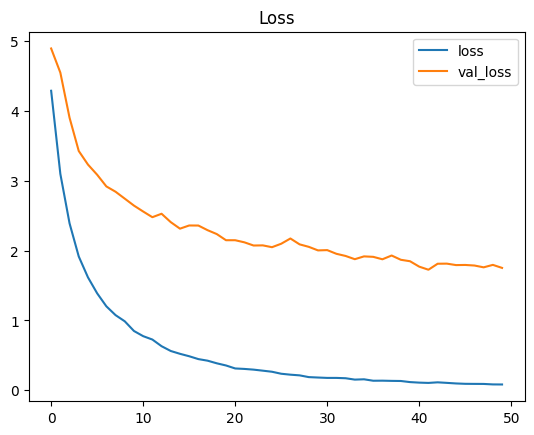

In [ ]:
loss = hist.history["loss"]
val_loss = hist.history["val_loss"]

plt.plot(loss, label="loss")
plt.plot(val_loss, label="val_loss")
plt.title("Loss")
plt.legend()
plt.show()

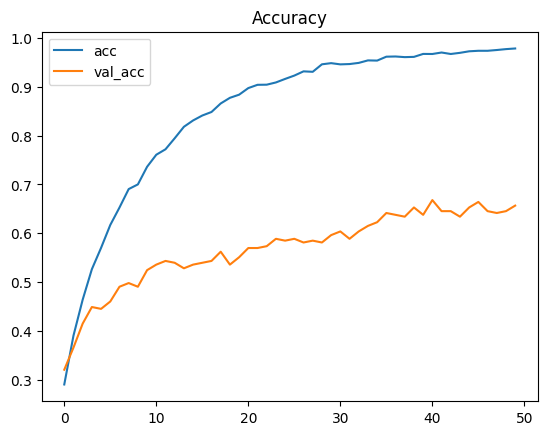

In [ ]:
acc = hist.history["sparse_categorical_accuracy"]
val_acc = hist.history["val_sparse_categorical_accuracy"]

plt.plot(acc, label="acc")
plt.plot(val_acc, label="val_acc")
plt.title("Accuracy")
plt.legend()
plt.show()

Podemos ver que solo funciona bien en train, lo que indica sobre ajuste.

In [ ]:

train_loss, train_acc = model.evaluate(X_train, y_train_num, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val_num, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test_num, verbose=0)

print("TRAIN:")
print("Loss:", round(train_loss,3))
print("Accuracy:", round(train_acc,3))

print("\nVALIDATION:")
print("Loss:", round(val_loss,3))
print("Accuracy:", round(val_acc,3))

print("\nTEST:")
print("Loss:", round(test_loss,3))
print("Accuracy:", round(test_acc,3))

TRAIN:
Loss: 0.011
Accuracy: 0.998

VALIDATION:
Loss: 1.752
Accuracy: 0.657

TEST:
Loss: 2.095
Accuracy: 0.634


# Matriz de confución

La matriz de confución muestra que el modelo tiene un rendimiento casí perfecto.

9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 577ms/step


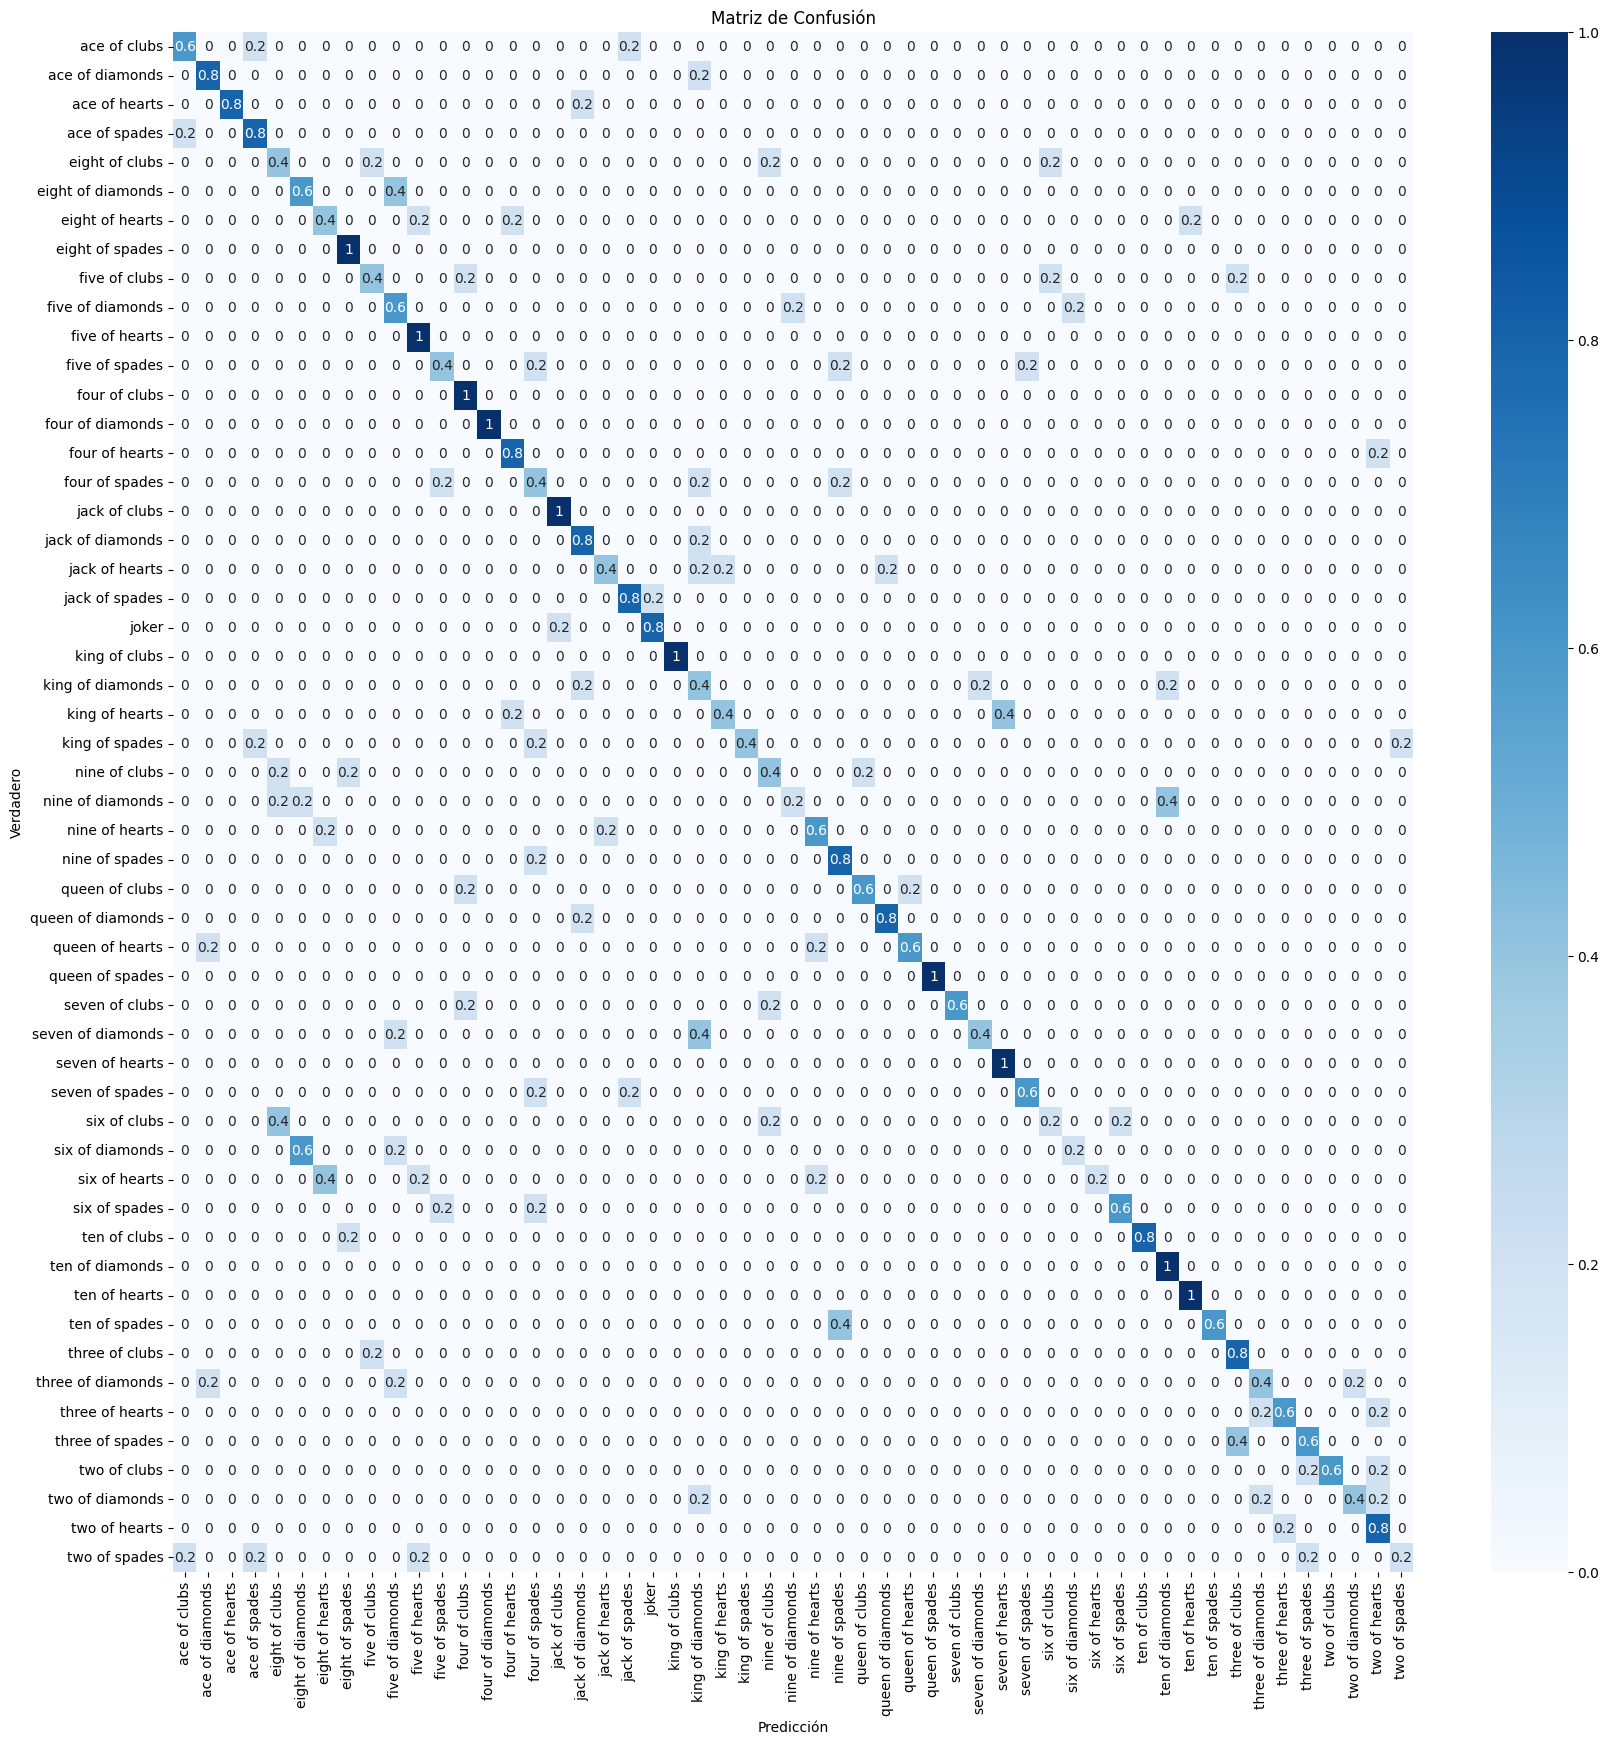

In [ ]:
class_names = encoder.classes_

cm = confusion_matrix(y_test_num, np.argmax(model.predict(X_test), axis=1), normalize="true")

plt.figure(figsize=(20, 20))
sns.heatmap(cm,
            annot=True, cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=True)

plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión')
plt.yticks(rotation=0)
plt.show()

# Conclusión

Este modelo parece ser nuestra mejor opción para resolver el problema, ya que, es el que goza de mejores metricas.